START HERE

In [1]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parents[0]
PROCESSED_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
OUTPUT_DIR = PROJECT_ROOT / 'figures' / 'pubmed_exploratory'

In [3]:
cell_authors = pd.read_csv(PROCESSED_DATA_DIR / 'cell_processed_author_data.csv')
nature_authors = pd.read_csv(PROCESSED_DATA_DIR / 'nature_processed_author_data.csv')

In [4]:
cell_authors['publication'] = 'Cell'
nature_authors['publication'] = 'Nature'
cell_authors = cell_authors.set_index('PMID')
nature_authors = nature_authors.set_index('PMID')

In [5]:
# many publications especially at earlier time points only list the affiliation for the first author
# set that affiliation for authors with no affiliation listed
cell_authors['primary_country'] = cell_authors['primary_country'].replace('No affiliation', np.nan)
cell_authors['primary_country'] = cell_authors['primary_country'].fillna(
    cell_authors.groupby('PMID')['primary_country'].transform('first'))

nature_authors['primary_country'] = nature_authors['primary_country'].replace('No affiliation', np.nan)
nature_authors['primary_country'] = nature_authors['primary_country'].fillna(
    nature_authors.groupby('PMID')['primary_country'].transform('first'))

In [6]:
all_authors = pd.concat([cell_authors, nature_authors])

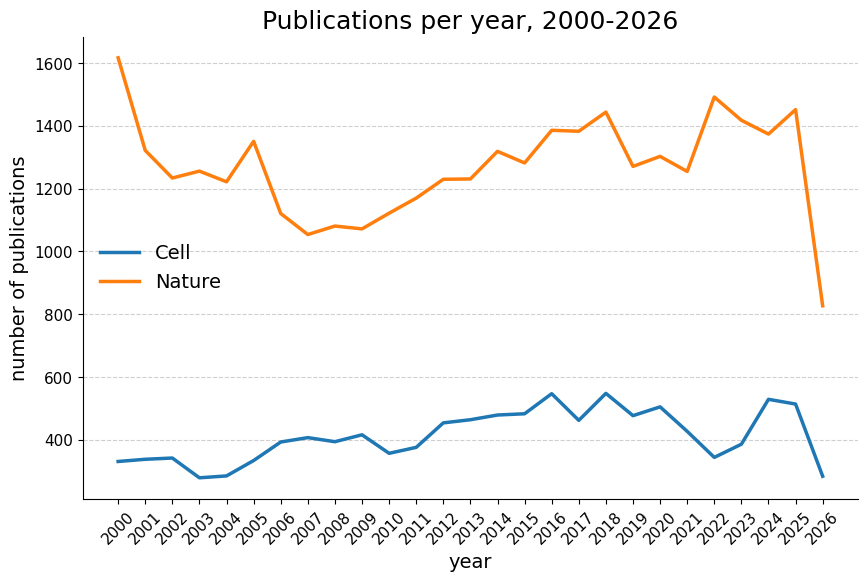

In [7]:
# plot number of publications over time
plot_df = all_authors.reset_index().groupby(['year', 'publication'])['PMID'].nunique().reset_index()
plt.figure(figsize=(10,6))
sns.lineplot(data = plot_df, x = 'year', y = 'PMID', hue = 'publication',
             linewidth = 2.5)
plt.title('Publications per year, 2000-2026', fontsize = 18)
plt.ylabel('number of publications', fontsize = 14)
plt.xlabel('year', fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.yticks(fontsize = 11)
plt.xticks(plot_df['year'].unique(), rotation=45, fontsize = 11)
plt.legend(frameon=False, fontsize = 14)
sns.despine()
plt.savefig(OUTPUT_DIR / 'publications_per_year.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)

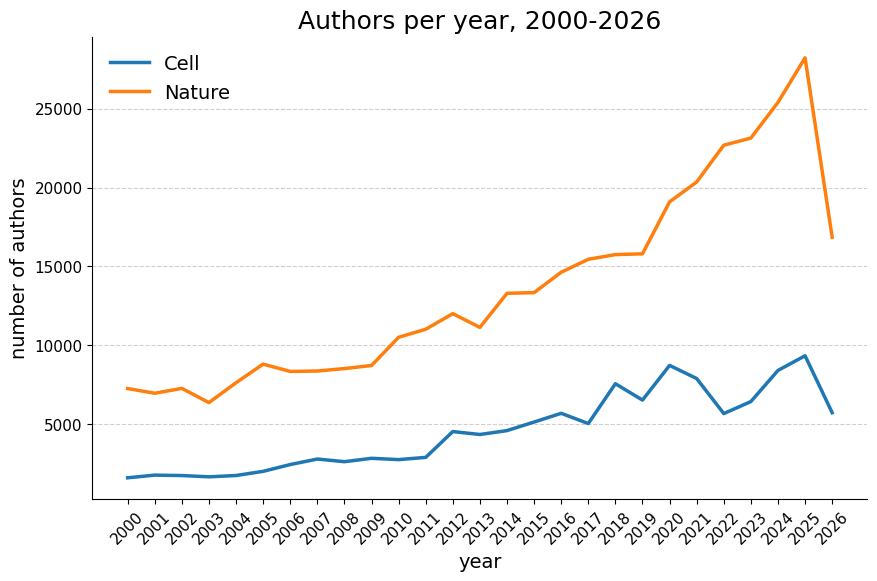

In [8]:
# plot number of authors over time
plot_df = all_authors.reset_index().groupby(['year', 'publication']).size().reset_index(name='num_authors')
plt.figure(figsize=(10,6))
sns.lineplot(data = plot_df, x = 'year', y = 'num_authors', hue = 'publication',
             linewidth = 2.5)
plt.title('Authors per year, 2000-2026', fontsize = 18)
plt.ylabel('number of authors', fontsize = 14)
plt.xlabel('year', fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.yticks(fontsize = 11)
plt.xticks(plot_df['year'].unique(), rotation=45, fontsize = 11)
plt.legend(frameon=False, fontsize = 14)
sns.despine()
plt.savefig(OUTPUT_DIR / 'authors_per_year.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)

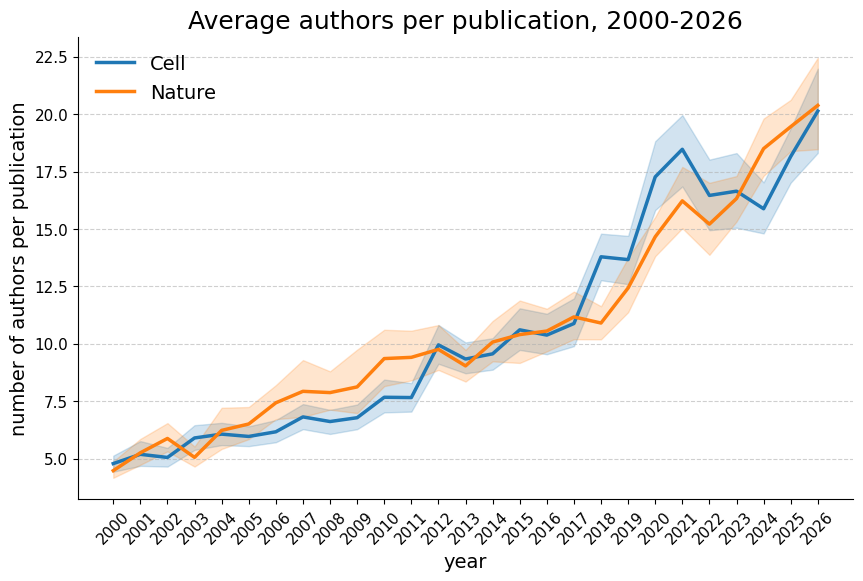

In [9]:
# plot average number of authors per publication over time
plot_df = all_authors.reset_index().groupby(['year', 'publication', 'PMID']).size().reset_index(name='authors_per_paper')
plt.figure(figsize=(10,6))
sns.lineplot(data = plot_df, x = 'year', y = 'authors_per_paper', hue = 'publication',
             linewidth = 2.5,
             estimator = 'mean')
plt.title('Average authors per publication, 2000-2026', fontsize = 18)
plt.ylabel('number of authors per publication', fontsize = 14)
plt.xlabel('year', fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.yticks(fontsize = 11)
plt.xticks(plot_df['year'].unique(), rotation=45, fontsize = 11)
plt.legend(frameon=False, fontsize = 14)
sns.despine()
plt.savefig(OUTPUT_DIR / 'avg_authors_per_publication.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)

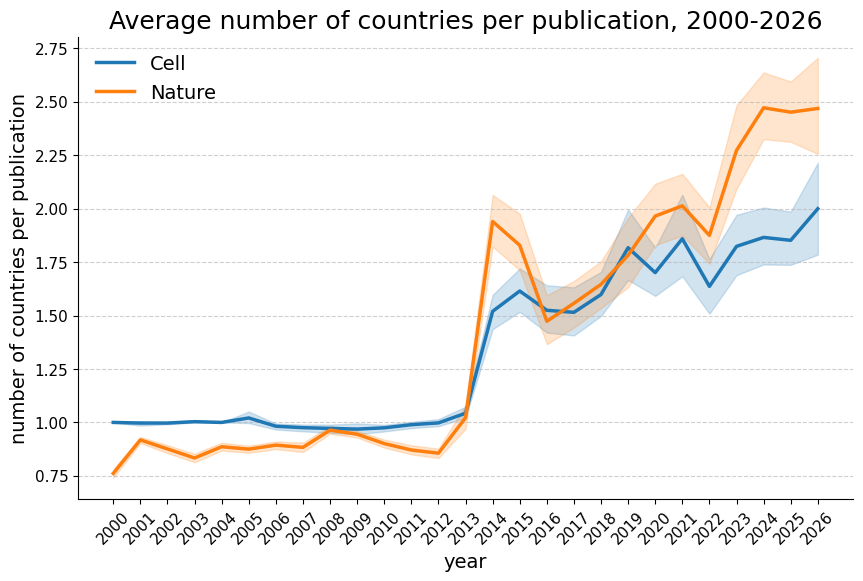

In [10]:
# plot average number of countries per publication over time
plot_df = all_authors.reset_index().groupby(['year', 'publication', 'PMID'])['primary_country'].nunique().reset_index(name='countries_per_paper')
plt.figure(figsize=(10,6))
sns.lineplot(data = plot_df, x = 'year', y = 'countries_per_paper', hue = 'publication',
             linewidth = 2.5,
             estimator = 'mean')
plt.title('Average number of countries per publication, 2000-2026', fontsize = 18)
plt.ylabel('number of countries per publication', fontsize = 14)
plt.xlabel('year', fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.yticks(fontsize = 11)
plt.xticks(plot_df['year'].unique(), rotation=45, fontsize = 11)
plt.legend(frameon=False, fontsize = 14)
sns.despine()
plt.savefig(OUTPUT_DIR / 'avg_countries_per_publication.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)

In [11]:
# since affiliations were not fully recored before 2014, restrict
# rest of analysis to post 2014 data. Also restrict to countries that
# appear more than 25 times

filtered = all_authors[all_authors['year'] >= 2014].dropna()

filtered = filtered[filtered['primary_country'].map(filtered['primary_country'].value_counts() > 25)]



In [12]:
# 1. Drop duplicates to ensure we only count a country once per PMID 
# (e.g., if a paper has 3 USA authors, we only want USA listed once for that paper)
df_unique = filtered.reset_index().drop_duplicates(subset=['PMID', 'primary_country'])

# 2. Merge the dataframe with itself on PMID to create all country pairs
pairs = df_unique.merge(df_unique, on='PMID', suffixes=('_target', '_partner'))

# 3. Filter out self-matches (we don't want to count USA pairing with USA)
pairs = pairs[pairs['primary_country_target'] != pairs['primary_country_partner']]

# 4. Group by the two country columns and count the occurrences
co_occurrences = pairs.groupby(['primary_country_target', 'primary_country_partner']).size().reset_index(name='Count')

# 5. Sort the results so the highest counts appear first
co_occurrences = co_occurrences.sort_values(by=['primary_country_target', 'Count'], ascending=[True, False])

co_occurrences[co_occurrences['primary_country_target'] == 'Japan']

,primary_country_target,primary_country_partner,Count
3303,Japan,USA,748
3245,Japan,Germany,307
3302,Japan,UK,307
3228,Japan,China,212
3242,Japan,France,196
...,...,...,...
3277,Japan,Republic of Singapore,1
3280,Japan,Rwanda,1
3282,Japan,Scotland,1
3285,Japan,Sierra Leone,1


In [13]:
matrix = co_occurrences.pivot(index='primary_country_target', columns='primary_country_partner', values='Count').fillna(0)

In [14]:
# get the top 10 countries by number of publications that they feature on
top_5 = list(filtered['primary_country'].value_counts().iloc[0:5].index)
top_6 = list(filtered['primary_country'].value_counts().iloc[0:6].index)
top_20 = list(filtered['primary_country'].value_counts().iloc[0:20].index)

In [15]:
# drop duplicates based on PMID and country so that only a single country
# is preserved per PMID
df_unique = filtered.reset_index().drop_duplicates(subset=['PMID', 'primary_country']).copy()

# groupby PMID and count countries to get unique countries per paper
df_unique['total_countries'] = df_unique.groupby('PMID')['primary_country'].transform('count')

# for each row, subtract 1 to get the number of countries aside from
# that country that contributed to the paper
df_unique['other_countries'] = df_unique['total_countries'] - 1

# for each primary country, compute crosstab to get frequency of collaborations
# with other countries
collaboration_counts = pd.crosstab(
    index=df_unique['primary_country'], 
    columns=df_unique['other_countries']
)

#sum up values over 15 to get an aggregate value for papers with over
# 15 collaborating countries
cond = collaboration_counts.columns[collaboration_counts.columns > 15]
collaboration_counts['>15'] = collaboration_counts[cond].sum(axis=1)
collaboration_counts = collaboration_counts.drop(columns = cond)
collaboration_counts

# normalize the collab counts by the sum of papers
norm_collab_counts = collaboration_counts.div(collaboration_counts.sum(axis=1),axis=0)

norm_collab_counts

other_countries,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,>15
primary_country,,,,,,,,,,,,,,,,,
Argentina,0.018018,0.117117,0.135135,0.063063,0.090090,0.090090,0.072072,0.036036,0.063063,0.027027,0.009009,0.027027,0.027027,0.036036,0.000000,0.009009,0.180180
Australia,0.067663,0.231107,0.185413,0.122144,0.095782,0.057118,0.042179,0.031634,0.033392,0.027241,0.011424,0.013181,0.013181,0.010545,0.004394,0.004394,0.049209
Austria,0.108541,0.227758,0.177936,0.090747,0.048043,0.046263,0.051601,0.049822,0.021352,0.019573,0.016014,0.012456,0.007117,0.014235,0.014235,0.014235,0.080071
Bangladesh,0.000000,0.235294,0.176471,0.058824,0.117647,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.411765
Belgium,0.045290,0.182971,0.202899,0.141304,0.081522,0.065217,0.048913,0.041667,0.019928,0.032609,0.018116,0.016304,0.009058,0.016304,0.009058,0.009058,0.059783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
United Arab Emirates,0.037736,0.207547,0.132075,0.056604,0.056604,0.056604,0.000000,0.000000,0.113208,0.000000,0.037736,0.000000,0.037736,0.075472,0.018868,0.037736,0.132075
Venezuela,0.000000,0.000000,0.000000,0.133333,0.000000,0.066667,0.000000,0.000000,0.000000,0.133333,0.000000,0.000000,0.133333,0.000000,0.000000,0.066667,0.466667
Vietnam,0.000000,0.000000,0.111111,0.000000,0.111111,0.111111,0.000000,0.000000,0.000000,0.111111,0.000000,0.000000,0.000000,0.055556,0.055556,0.000000,0.444444


In [16]:
# transform normalized counts to long format for plotting
long_counts = norm_collab_counts.reset_index().melt(
    id_vars = 'primary_country',
    var_name = 'num_collab_countries',
    value_name = 'proportion'
)
# change value to str for plotting appropriately
long_counts['num_collab_countries'] = long_counts['num_collab_countries'].astype(str)

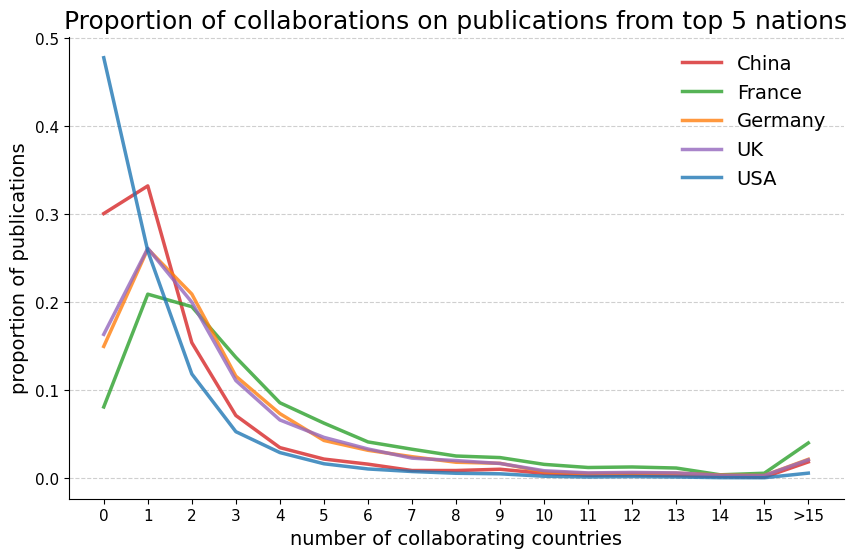

In [17]:
cond = long_counts['primary_country'].isin(top_5)

country_colors = {
    'USA': '#1f77b4',     # Hex code for a nice blue
    'Germany': '#ff7f0e',  # Orange
    'China': '#d62728',   # Red
    'France': '#2ca02c',   # Green
    'UK': '#9467bd', # Purple
}


plt.figure(figsize=(10,6))
ax = sns.lineplot(
    data = long_counts[cond],
    x = 'num_collab_countries',
    y = 'proportion',
    hue = 'primary_country',
    linewidth = 2.5,
    alpha = 0.8,
    palette= country_colors
)
plt.title('Proportion of collaborations on publications from top 5 nations', fontsize = 18)
plt.ylabel('proportion of publications', fontsize = 14)
plt.xlabel('number of collaborating countries', fontsize = 14)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.yticks(fontsize = 11)
plt.xticks(rotation=0, fontsize = 11)
plt.legend(frameon=False, fontsize = 14)
sns.despine()
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
plt.savefig(OUTPUT_DIR / 'proportion_collab_countries_top_5.png',
            dpi = 300,
            bbox_inches = 'tight',
            transparent = True)


In [18]:
collaboration_counts.to_csv(PROCESSED_DATA_DIR / 'collab_counts.csv')
norm_collab_counts.to_csv(PROCESSED_DATA_DIR / 'norm_collab_counts.csv')
co_occurrences.to_csv(PROCESSED_DATA_DIR / 'country_co-occurences.csv')

In [19]:
filtered.head()

,year,author,affiliations,primary_affiliation,primary_country,publication
PMID,,,,,,
25557080,2014,Sylvia F Boj,"['Hubrecht Institute, Royal Netherlands Academ...","Hubrecht Institute, Royal Netherlands Academy ...",the Netherlands,Cell
25557080,2014,Chang-Il Hwang,"['Cold Spring Harbor Laboratory, Cold Spring H...","Cold Spring Harbor Laboratory, Cold Spring Har...",USA,Cell
25557080,2014,Lindsey A Baker,"['Cold Spring Harbor Laboratory, Cold Spring H...","Cold Spring Harbor Laboratory, Cold Spring Har...",USA,Cell
25557080,2014,Iok In Christine Chio,"['Cold Spring Harbor Laboratory, Cold Spring H...","Cold Spring Harbor Laboratory, Cold Spring Har...",USA,Cell
25557080,2014,Dannielle D Engle,"['Cold Spring Harbor Laboratory, Cold Spring H...","Cold Spring Harbor Laboratory, Cold Spring Har...",USA,Cell


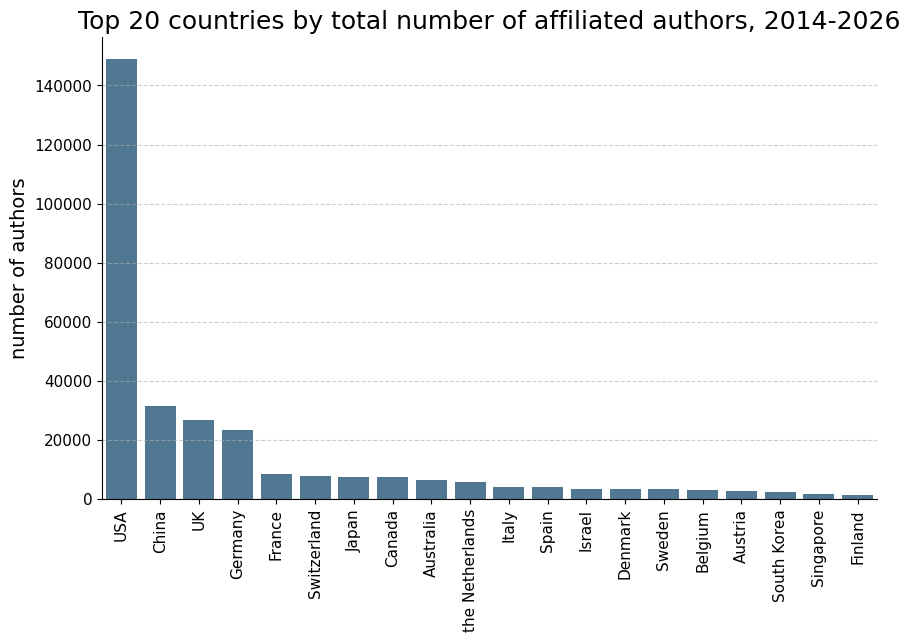

In [46]:
#### TOP 20 total authors
plot_series = filtered['primary_country'].value_counts()[0:20]
plt.figure(figsize=(10,6))
sns.barplot(data=plot_series, color = '#457b9d')
plt.title('Top 20 countries by total number of affiliated authors, 2014-2026', fontsize = 18)
plt.ylabel('number of authors', fontsize = 14)
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.yticks(fontsize = 11)
plt.xticks(plot_series.index.unique(), rotation=90, fontsize = 11)
sns.despine()

<Axes: xlabel='year', ylabel='count'>

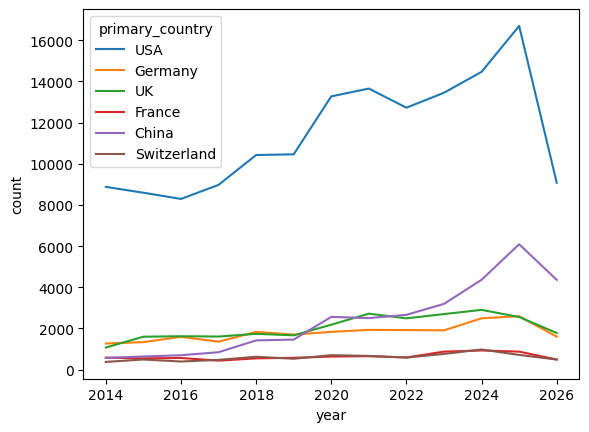

In [ ]:
# top_20 = list(filtered['primary_country'].value_counts().iloc[0:20].index)
### NUMBER OF AUTHORS FROM DIFFERENT COUNTRIES AFFILIATIONS OVER TIME
plot_data = filtered.groupby('year')['primary_country'].value_counts().reset_index()
plot_data_filtered = plot_data[plot_data['primary_country'].isin(top_6)]
plot_data_filtered.head()
sns.lineplot(data = plot_data_filtered, x = 'year', y = 'count', hue = 'primary_country')

(0.0, 100000.0)

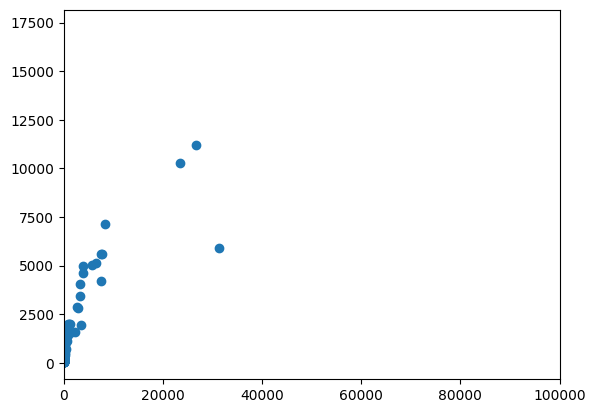

In [61]:
collaborations = co_occurrences.groupby('primary_country_target')['Count'].sum()
total_authors = filtered['primary_country'].value_counts()
collab_total_authors = pd.merge(collaborations, total_authors, left_index=True, right_index=True, how = 'inner').rename(columns={'Count': 'collaborations', 'count':'total_authors'})
collab_total_authors.head()
plt.scatter(data=collab_total_authors, x = 'total_authors', y = 'collaborations')
plt.xlim(0,100000)

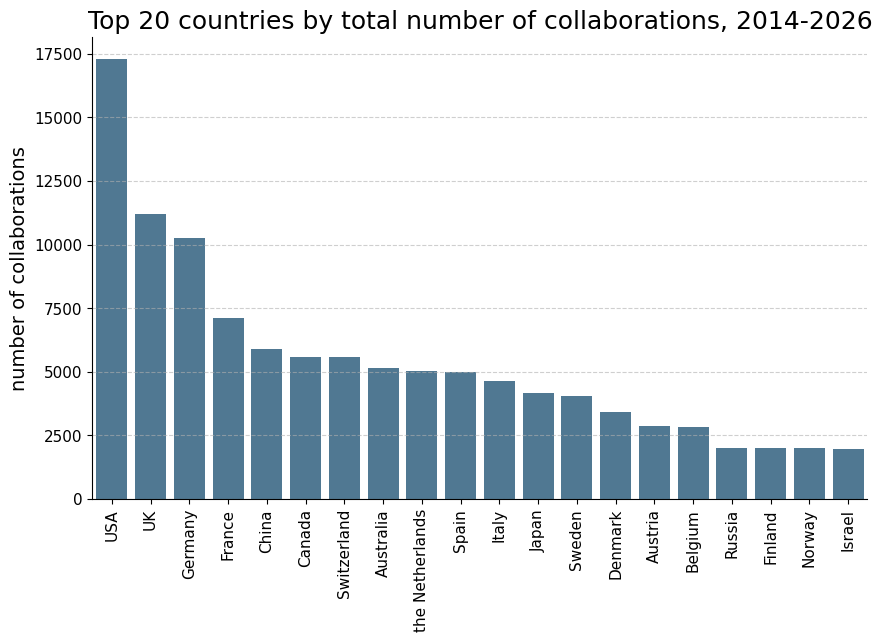

In [47]:
plot_series = co_occurrences.groupby('primary_country_target')['Count'].sum().sort_values(ascending=False)[0:20]
plt.figure(figsize=(10,6))
sns.barplot(data=plot_series, color = '#457b9d')
plt.title('Top 20 countries by total number of collaborations, 2014-2026', fontsize = 18)
plt.ylabel('number of collaborations', fontsize = 14)
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.yticks(fontsize = 11)
plt.xticks(plot_series.index.unique(), rotation=90, fontsize = 11)
sns.despine()
# plt.savefig(OUTPUT_DIR / 'total_student_flux_top_bottom_10.png',
#             dpi = 300,
#             bbox_inches = 'tight',
#             transparent = True)

In [65]:
plot_data = filtered.reset_index().drop_duplicates(subset=['PMID','primary_country'])
plot_series = plot_data['primary_country'].value_counts()
plot_series

primary_country
USA                                                            13057
UK                                                              3641
Germany                                                         3313
China                                                           2768
France                                                          1686
                                                               ...  
Republic of Singapore                                              5
ROC                                                                4
U.K                                                                4
MO                                                                 2
and part of the Study Reporting in Predatory Journals Group        1
Name: count, Length: 104, dtype: int64

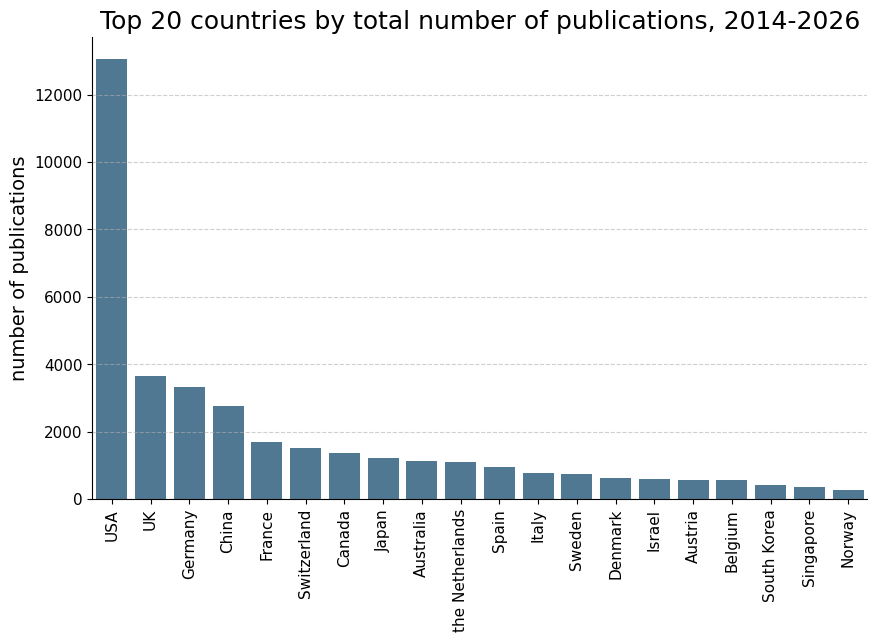

In [66]:
plot_data = filtered.reset_index().drop_duplicates(subset=['PMID','primary_country'])
plot_series = plot_data['primary_country'].value_counts()[0:20]
plt.figure(figsize=(10,6))
sns.barplot(data=plot_series, color = '#457b9d')
plt.title('Top 20 countries by total number of publications, 2014-2026', fontsize = 18)
plt.ylabel('number of publications', fontsize = 14)
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.yticks(fontsize = 11)
plt.xticks(plot_series.index.unique(), rotation=90, fontsize = 11)
sns.despine()

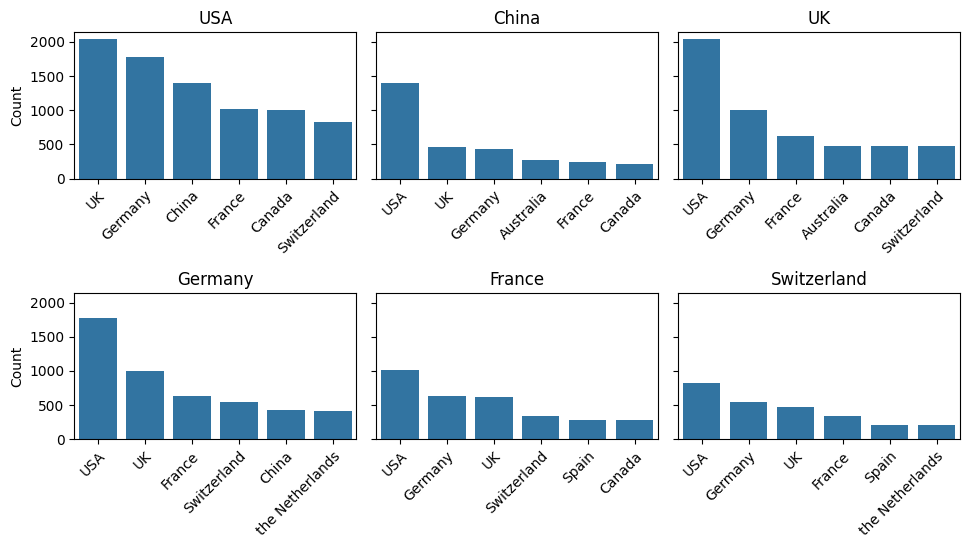

In [22]:
# co_occurrences.groupby('primary_country_target')['Count'].sum().sort_values(ascending=False)[0:30]
china = co_occurrences[co_occurrences['primary_country_target'] == 'China']
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (10,6), sharey=True)
axes = axes.flatten()
for i, country in enumerate(top_6):
    ax = axes[i]
    subset = co_occurrences[co_occurrences['primary_country_target']==country]
    sns.barplot(data = subset[0:6], x = 'primary_country_partner', y = 'Count', ax = ax)
    plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')
    ax.set_title(country)
    ax.set_xlabel('')
plt.tight_layout(rect=[0.02, 0.02, 1, 0.95])

FINAL MODEL CODE   

In [23]:
merged = pd.read_csv(PROCESSED_DATA_DIR / 'merged_student_data.csv')

In [24]:
merged.head()

,Unnamed: 0,geoUnit_inbound,year,students_inbound,country,students_outbound,flux,total_exchange
0,0,AFG,2000,NaN,Afghanistan,2454.0,NaN,NaN
1,1,AFG,2001,NaN,Afghanistan,2467.0,NaN,NaN
2,2,AFG,2002,NaN,Afghanistan,2544.0,NaN,NaN
3,3,AFG,2003,NaN,Afghanistan,2549.0,NaN,NaN
4,4,AFG,2004,NaN,Afghanistan,2612.0,NaN,NaN


In [25]:
collaboration_counts.head()

other_countries,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,>15
primary_country,,,,,,,,,,,,,,,,,
Argentina,2,13,15,7,10,10,8,4,7,3,1,3,3,4,0,1,20
Australia,77,263,211,139,109,65,48,36,38,31,13,15,15,12,5,5,56
Austria,61,128,100,51,27,26,29,28,12,11,9,7,4,8,8,8,45
Bangladesh,0,4,3,1,2,0,0,0,0,0,0,0,0,0,0,0,7
Belgium,25,101,112,78,45,36,27,23,11,18,10,9,5,9,5,5,33


In [26]:
collaboration_counts.columns

Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, '>15'], dtype='object', name='other_countries')

In [27]:
collaboration_counts.loc['Argentina', 1:'>15']
collaboration_counts[]

SyntaxError: invalid syntax (964975381.py, line 2)

In [29]:
collaboration_counts['total_collabs'] = collaboration_counts[[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,'>15']].sum(axis=1)
collaboration_counts['solo_collab_ratio'] = collaboration_counts[0].div(collaboration_counts['total_collabs'] + collaboration_counts[0])
collaboration_counts['total_publications'] = collaboration_counts[[0, 'total_collabs']].sum(axis=1)
collaboration_counts.head()

other_countries,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,>15,total_collabs,solo_collab_ratio,total_publications
primary_country,,,,,,,,,,,,,,,,,,,,
Argentina,2,13,15,7,10,10,8,4,7,3,1,3,3,4,0,1,20,109,0.018018,111
Australia,77,263,211,139,109,65,48,36,38,31,13,15,15,12,5,5,56,1061,0.067663,1138
Austria,61,128,100,51,27,26,29,28,12,11,9,7,4,8,8,8,45,501,0.108541,562
Bangladesh,0,4,3,1,2,0,0,0,0,0,0,0,0,0,0,0,7,17,0.000000,17
Belgium,25,101,112,78,45,36,27,23,11,18,10,9,5,9,5,5,33,527,0.045290,552


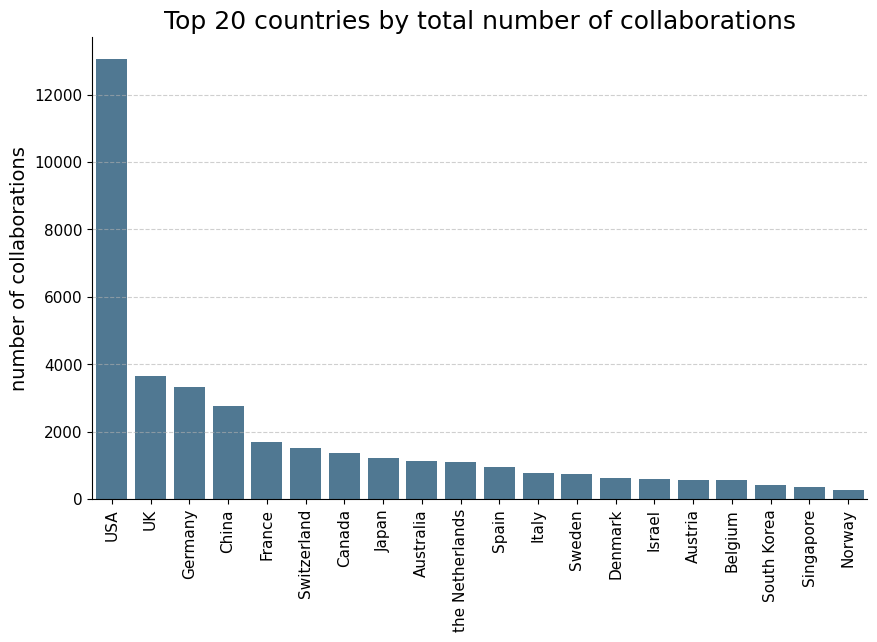

In [31]:
plot_series = collaboration_counts['total_publications'].sort_values(ascending=False)[0:20]
plt.figure(figsize=(10,6))
sns.barplot(data=plot_series, color = '#457b9d')
plt.title('Top 20 countries by total number of collaborations', fontsize = 18)
plt.ylabel('number of collaborations', fontsize = 14)
plt.xlabel('')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.yticks(fontsize = 11)
plt.xticks(plot_series.index.unique(), rotation=90, fontsize = 11)
sns.despine()

In [68]:
total_inbound = merged.groupby('country')['students_inbound'].sum()
total_outbound = merged.groupby('country')['students_outbound'].sum()
total_exchange = merged.groupby('country')['total_exchange'].sum()


In [ ]:
collaboration_counts.sort_values(by='total_collabs', ascending = False)

other_countries,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,>15,total_collabs,collab_solo_ratio,solo_collab_ratio
primary_country,,,,,,,,,,,,,,,,,,,,
USA,6229,3366,1540,693,382,216,141,102,76,69,33,22,27,22,12,11,79,6791,0.478418,0.478418
UK,593,950,726,404,242,168,122,83,73,62,32,23,24,23,13,12,77,3034,0.163496,0.163496
Germany,495,861,690,383,243,143,106,81,60,57,25,19,19,20,13,11,72,2803,0.150091,0.150091
China,829,916,421,197,95,60,45,25,24,29,16,10,10,9,6,4,52,1919,0.301674,0.301674
France,137,352,328,232,144,106,70,55,43,40,27,21,21,20,7,10,68,1544,0.081499,0.081499
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Republic of Singapore,0,2,1,0,0,1,0,0,0,0,0,0,0,0,0,0,1,5,0.000000,0.000000
U.K,0,1,1,0,2,0,0,0,0,0,0,0,0,0,0,0,0,4,0.000000,0.000000
ROC,0,0,2,1,0,0,0,0,0,0,0,0,0,0,0,0,1,4,0.000000,0.000000


In [140]:
unesco_pubmed = pd.merge(total_inbound, total_outbound, left_index=True, right_index=True)
unesco_pubmed = pd.merge(unesco_pubmed, total_exchange, left_index=True, right_index=True)
unesco_pubmed = pd.merge(unesco_pubmed, collaboration_counts, left_index=True, right_index=True, how='inner')
unesco_pubmed['collab_ratio'] = unesco_pubmed['total_collabs'] / (unesco_pubmed['total_collabs'] + unesco_pubmed[0])
unesco_pubmed.head()

,students_inbound,students_outbound,total_exchange,0,1,2,3,4,5,6,...,11,12,13,14,15,>15,total_collabs,solo_collab_ratio,total_publications,collab_ratio
country,,,,,,,,,,,,,,,,,,,,,
Argentina,1.488498e+06,210524.0,1.699022e+06,2,13,15,7,10,10,8,...,3,3,4,0,1,20,109,0.018018,111,0.981982
Australia,6.772983e+06,264501.0,7.037484e+06,77,263,211,139,109,65,48,...,15,15,12,5,5,56,1061,0.067663,1138,0.932337
Austria,1.413283e+06,418530.0,1.831813e+06,61,128,100,51,27,26,29,...,7,4,8,8,8,45,501,0.108541,562,0.891459
Bangladesh,3.418700e+04,816842.0,8.318180e+05,0,4,3,1,2,0,0,...,0,0,0,0,0,7,17,0.000000,17,1.000000
Belgium,1.030955e+06,313441.0,1.344396e+06,25,101,112,78,45,36,27,...,9,5,9,5,5,33,527,0.045290,552,0.954710


In [151]:
# unesco_pubmed_rm = unesco_pubmed.drop(['USA', 'China'])
test = collaboration_counts.join([total_exchange, total_inbound, total_outbound], how = 'inner')
unesco_pubmed_ig.head()

,students_inbound,students_outbound,total_exchange,0,1,2,3,4,5,6,...,11,12,13,14,15,>15,total_collabs,solo_collab_ratio,total_publications,collab_ratio
country,,,,,,,,,,,,,,,,,,,,,
Argentina,1.488498e+06,210524.0,1.699022e+06,2,13,15,7,10,10,8,...,3,3,4,0,1,20,109,0.018018,111,0.981982
Australia,6.772983e+06,264501.0,7.037484e+06,77,263,211,139,109,65,48,...,15,15,12,5,5,56,1061,0.067663,1138,0.932337
Austria,1.413283e+06,418530.0,1.831813e+06,61,128,100,51,27,26,29,...,7,4,8,8,8,45,501,0.108541,562,0.891459
Bangladesh,3.418700e+04,816842.0,8.318180e+05,0,4,3,1,2,0,0,...,0,0,0,0,0,7,17,0.000000,17,1.000000
Belgium,1.030955e+06,313441.0,1.344396e+06,25,101,112,78,45,36,27,...,9,5,9,5,5,33,527,0.045290,552,0.954710


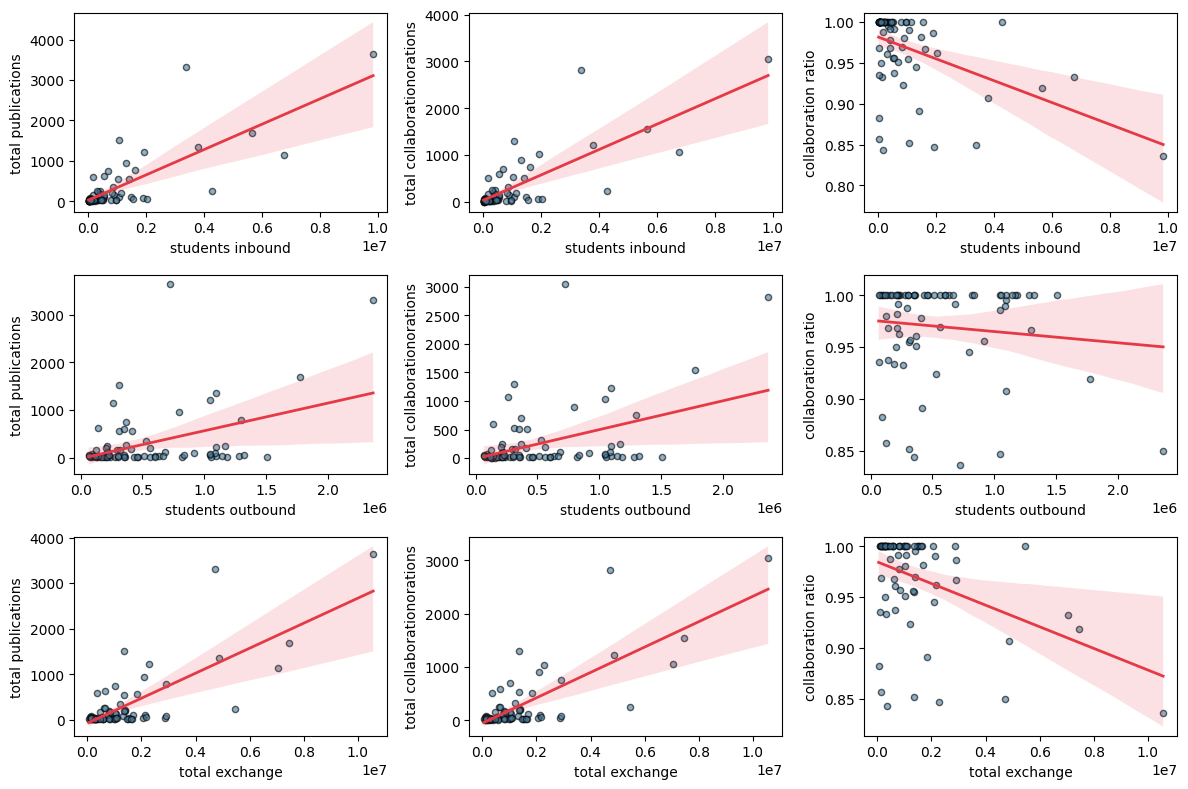

In [177]:
# plt.scatter(x=(unesco_pubmed['students_outbound']), y = unesco_pubmed['solo_collab_ratio'])

ignore_list = ['USA', 'China', 'India']
unesco_pubmed_ig = unesco_pubmed.drop(ignore_list)

x_vars = ['students_inbound', 'students_outbound', 'total_exchange']
y_vars = ['total_publications', 'total_collabs', 'collab_ratio']



def get_lin_regress(df, x_var, y_var, x_log = False):
    slope, intercept, r_value, p_value, std_err = stats.linregress(
    np.log(df[x_var]) if x_log else df[x_var],
    df[y_var]
    )
    return slope, intercept, r_value, p_value, std_err

def plot_lin_regress(df, x_var, y_var,ax, log_x=False):
    return sns.regplot(data = unesco_pubmed_ig, x = x_var, y = y_var, ax=ax, logx=log_x,
        scatter_kws={
        'color': '#457b9d',
        'alpha': 0.6,       
        's': 20,           
        'edgecolor': 'black'
        },
        line_kws={
        'color': '#e63946', 
        'alpha': 1.0,     
        'linewidth': 2 
    })

fig, axes = plt.subplots(nrows = 3, ncols = 3, figsize = (12,8))
for i, x_var in enumerate(x_vars):
    for j, y_var in enumerate(y_vars):
        ax = axes[i,j]
        slope, intercept, r_value, p_value, std_err = get_lin_regress(unesco_pubmed_ig, x_var, y_var, x_log = False)
        plot_lin_regress(unesco_pubmed_ig, x_var, y_var, ax, log_x = False)
        ax.set_xlabel(x_var.replace('_', ' '))
        ax.set_ylabel(y_var.replace('_', ' ').replace('collabs', 'collaborations').replace('collab', 'collaboration'))
plt.tight_layout()
        

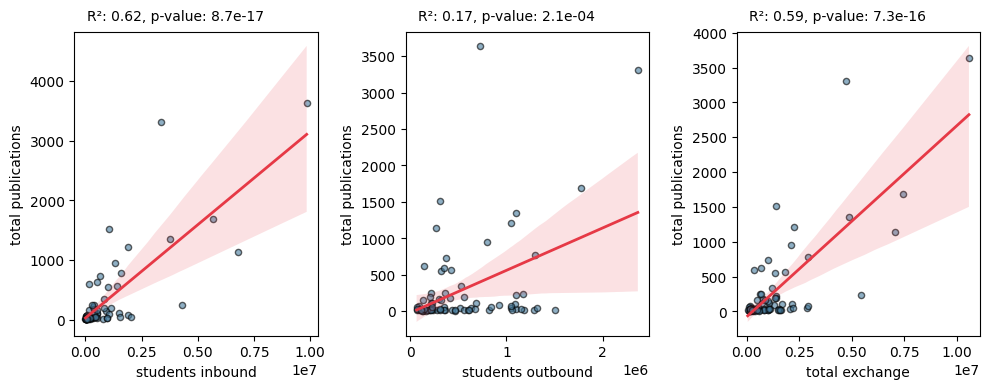

In [190]:
fig, axes = plt.subplots(nrows = 1, ncols = 3, figsize = (10,4))
axes = axes.flatten()
y_var = y_vars[0]
for i, x_var in enumerate(x_vars):
        ax = axes[i]
        slope, intercept, r_value, p_value, std_err = get_lin_regress(unesco_pubmed_ig, x_var, y_var)
        plot_lin_regress(unesco_pubmed_ig, x_var, y_var, ax)
        ax.set_xlabel(x_var.replace('_', ' '))
        ax.set_ylabel(y_var.replace('_', ' ').replace('collabs', 'collaborations').replace('collab', 'collaboration'))
        ax.text(
        x=0.05, 
        y=1.075, 
        s=f'R\u00B2: {r_value**2:.2f}, p-value: {p_value:.1e}', 
        transform=ax.transAxes, 
        verticalalignment='top', # Aligns the top of the text to the 0.95 mark
        fontsize=10
        )
        
plt.tight_layout()

In [148]:
'total_collabs'.replace('collabs', 'collaborations').replace('_', ' ')

'total collaborations'

In [ ]:
import statsmodels.api as sm

# Keep original setup: Happiness predicts GDP
X_real = df_merged['ladder_score']
y_real = df_merged['gdp_per_capita']
X_real_const = sm.add_constant(X_real)
X_real_const.head(2)